In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_URL = "https://github.com/kabdoullah/plant-disease-classification.git"
if os.path.exists('/content/project/.git'):
    !git -C /content/project pull
else:
    !git clone {REPO_URL} /content/project

!pip install -q timm

import sys
if '/content/project' not in sys.path:
    sys.path.insert(0, '/content/project')

from src import config
from src.utils import set_seed, get_device, count_parameters, file_size_mb
set_seed(config.SEED)
device = get_device()
print("Device :", device, "|", config.NUM_CLASSES, "classes")

Mounted at /content/drive
Cloning into '/content/project'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 51 (delta 20), reused 42 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 16.97 KiB | 3.39 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Device : cpu | 5 classes


In [2]:
import json
from pathlib import Path
from src.data.loaders import get_dataloaders
from src.models.build import build_model
from src.utils import load_checkpoint

DATA_DIR = "/content/data/tomato5"
if not Path(DATA_DIR).exists():
    !mkdir -p /content/data && unzip -q {config.DRIVE_ROOT}/dataset/tomato5.zip -d /content/data

saved = json.loads((config.RESULTS_DIR / "splits.json").read_text())
assert saved["classes"] == config.CLASSES
splits = {k: saved[k] for k in ("train", "val", "test")}
loaders = get_dataloaders(DATA_DIR, splits)

models = {}
for kind, name in [("cnn", "ResNet18"), ("vit", "ViT-Tiny")]:
    m, _ = build_model(kind, pretrained=False)   # poids écrasés juste après
    ck = load_checkpoint(config.MODELS_DIR / f"{kind}_best.pt", model=m, device=device)
    models[kind] = m
    print(f"{name:10s} epoch {ck['epoch']:2d} | val acc {ck['metadata'].get('val_acc'):.4f}")

ResNet18   epoch 14 | val acc 0.8833
ViT-Tiny   epoch 14 | val acc 0.9100


In [3]:
from src.evaluation.evaluate import predict_all, compute_metrics, per_class_report

results = {}
for kind in ("cnn", "vit"):
    y_true, y_pred, y_proba = predict_all(models[kind], loaders["test"], device)
    results[kind] = {"y_true": y_true, "y_pred": y_pred, "y_proba": y_proba,
                     "metrics": compute_metrics(y_true, y_pred)}
    print(f"\n{'='*55}\n{kind.upper()}\n{'='*55}")
    print(per_class_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



CNN
                                precision    recall  f1-score   support

             Tache bactérienne     0.8125    0.8667    0.8387        60
Alternariose (mildiou précoce)     0.6232    0.7167    0.6667        60
                Mildiou tardif     0.7963    0.7167    0.7544        60
                    Septoriose     0.8462    0.7333    0.7857        60
                 Feuille saine     0.9836    1.0000    0.9917        60

                      accuracy                         0.8067       300
                     macro avg     0.8123    0.8067    0.8074       300
                  weighted avg     0.8123    0.8067    0.8074       300



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



VIT
                                precision    recall  f1-score   support

             Tache bactérienne     0.8286    0.9667    0.8923        60
Alternariose (mildiou précoce)     0.8367    0.6833    0.7523        60
                Mildiou tardif     0.8644    0.8500    0.8571        60
                    Septoriose     0.8983    0.8833    0.8908        60
                 Feuille saine     0.9365    0.9833    0.9593        60

                      accuracy                         0.8733       300
                     macro avg     0.8729    0.8733    0.8704       300
                  weighted avg     0.8729    0.8733    0.8704       300



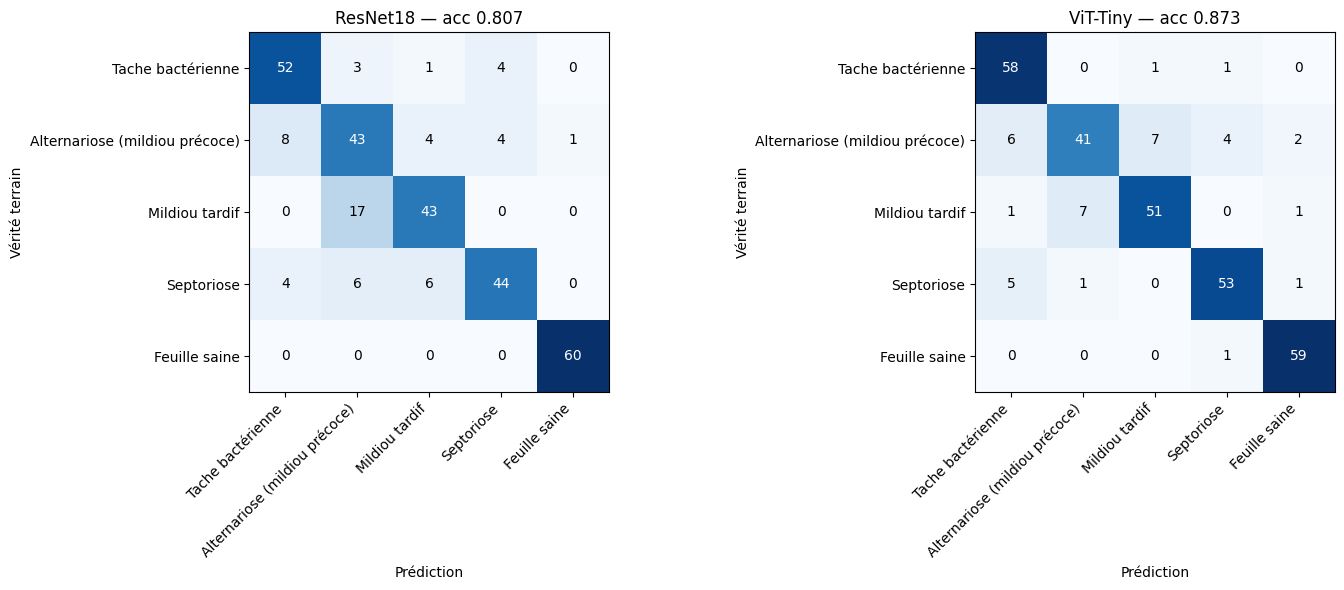

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from src.evaluation.evaluate import get_confusion

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
labels = [config.CLASS_LABELS_FR[c] for c in config.CLASSES]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (kind, title) in zip(axes, [("cnn", "ResNet18"), ("vit", "ViT-Tiny")]):
    cm = get_confusion(results[kind]["y_true"], results[kind]["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Vérité terrain")
    ax.set_title(f"{title} — acc {results[kind]['metrics']['accuracy']:.3f}")
    thr = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black")
plt.tight_layout()
plt.savefig(FIG_DIR / "matrices_confusion.png", dpi=150)
plt.show()

In [5]:
from scipy.stats import binomtest
from src.evaluation.evaluate import mcnemar_table

y_true = results["cnn"]["y_true"]
tab = mcnemar_table(y_true, results["cnn"]["y_pred"], results["vit"]["y_pred"])

print("Table de contingence appariée (n =", len(y_true), ")")
print(f"  Les deux corrects        : {tab['both_correct']}")
print(f"  CNN seul correct    (b)  : {tab['only_a']}")
print(f"  ViT seul correct    (c)  : {tab['only_b']}")
print(f"  Les deux en erreur       : {tab['both_wrong']}")

b, c = tab["only_a"], tab["only_b"]
if b + c == 0:
    print("\nAucun désaccord — modèles indiscernables sur ce jeu.")
else:
    p = binomtest(b, b + c, 0.5).pvalue
    print(f"\nMcNemar exact : n désaccords = {b+c}, p = {p:.4f}")
    print("→ Écart SIGNIFICATIF (p < 0.05)" if p < 0.05
          else "→ Écart NON significatif : les deux modèles ne peuvent "
               "être départagés sur ce jeu de test.")

Table de contingence appariée (n = 300 )
  Les deux corrects        : 226
  CNN seul correct    (b)  : 16
  ViT seul correct    (c)  : 36
  Les deux en erreur       : 22

McNemar exact : n désaccords = 52, p = 0.0078
→ Écart SIGNIFICATIF (p < 0.05)


In [6]:
from src.evaluation.evaluate import benchmark_cpu

for kind, name in [("cnn", "ResNet18"), ("vit", "ViT-Tiny")]:
    bench = benchmark_cpu(models[kind], loaders["test"])
    results[kind]["bench"] = bench
    print(f"{name:10s} médiane {bench['median_ms']:6.1f} ms | "
          f"moyenne {bench['mean_ms']:6.1f} ± {bench['std_ms']:.1f} ms")

# Remettre les modèles sur le device d'origine
for m in models.values():
    m.to(device)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet18   médiane   83.2 ms | moyenne   84.4 ± 4.5 ms
ViT-Tiny   médiane   54.2 ms | moyenne   65.4 ± 16.5 ms


In [7]:
import pandas as pd
from src.utils import count_parameters, file_size_mb

rows = []
for kind, name in [("cnn", "ResNet18"), ("vit", "ViT-Tiny")]:
    m, r = models[kind], results[kind]
    rows.append({
        "Modèle": name,
        "Accuracy": round(r["metrics"]["accuracy"], 4),
        "Précision (macro)": round(r["metrics"]["precision"], 4),
        "Rappel (macro)": round(r["metrics"]["recall"], 4),
        "F1 (macro)": round(r["metrics"]["f1"], 4),
        "Paramètres": count_parameters(m),
        "Poids (Mo)": round(file_size_mb(config.MODELS_DIR / f"{kind}_best.pt"), 1),
        "Inférence CPU (ms)": round(r["bench"]["median_ms"], 1),
    })

comparison = pd.DataFrame(rows)
display(comparison)
comparison.to_csv(config.RESULTS_DIR / "comparison.csv", index=False)

# Traces brutes, indispensables pour les annexes du rapport
np.savez(config.RESULTS_DIR / "test_predictions.npz",
         y_true=results["cnn"]["y_true"],
         cnn_pred=results["cnn"]["y_pred"], cnn_proba=results["cnn"]["y_proba"],
         vit_pred=results["vit"]["y_pred"], vit_proba=results["vit"]["y_proba"])
print("\nRésultats enregistrés dans Drive.")

,Modèle,Accuracy,Précision (macro),Rappel (macro),F1 (macro),Paramètres,Poids (Mo),Inférence CPU (ms)
0,ResNet18,0.8067,0.8123,0.8067,0.8074,11179077,42.7,83.2
1,ViT-Tiny,0.8733,0.8729,0.8733,0.8704,5525381,21.1,54.2



Résultats enregistrés dans Drive.
